In [1]:
from datasets import load_dataset, Dataset, load_from_disk
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
import copy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from rich import print as pprint
import numpy as np
import re
from openai import OpenAI


/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
ds = load_dataset("greengerong/leetcode")['train']

In [3]:
ds[0]

{'id': 1,
 'slug': 'two-sum',
 'title': 'Two Sum',
 'difficulty': 'Easy',
 'content': 'Given an array of integers `nums` and an integer `target`, return _indices of the two numbers such that they add up to `target`_.\n\nYou may assume that each input would have **_exactly_ one solution**, and you may not use the _same_ element twice.\n\nYou can return the answer in any order.\n\n**Example 1:**\n\n**Input:** nums = \\[2,7,11,15\\], target = 9\n**Output:** \\[0,1\\]\n**Explanation:** Because nums\\[0\\] + nums\\[1\\] == 9, we return \\[0, 1\\].\n\n**Example 2:**\n\n**Input:** nums = \\[3,2,4\\], target = 6\n**Output:** \\[1,2\\]\n\n**Example 3:**\n\n**Input:** nums = \\[3,3\\], target = 6\n**Output:** \\[0,1\\]\n\n**Constraints:**\n\n*   `2 <= nums.length <= 104`\n*   `-109 <= nums[i] <= 109`\n*   `-109 <= target <= 109`\n*   **Only one valid answer exists.**\n\n**Follow-up:** Can you come up with an algorithm that is less than `O(n2)` time complexity?',
 'java': '\n    ```java\nimport j

Using only 100 examples from each language

In [4]:
prompts = []
language = []

keep = 100

for l in ['java', 'c++', 'python', 'javascript']:
    for i in tqdm(range(min(keep, len(ds)))):
        prompts.append(ds[i][l].split('```')[1])
        language.append(l)

language = np.array(language)

100%|██████████| 100/100 [00:00<00:00, 23558.21it/s]


# Model

In [5]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '2,3'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

2


In [6]:
model_name = 'qwen'

if (model_name == 'llama'):

    tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-13B-Instruct", cache_dir='/data/takis/models')
    model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-13B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16, device_map='auto').to(device)

    model = model.eval()

elif (model_name == 'gemma'):

    tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-9b-it", cache_dir='/data/takis/models')
    model = AutoModelForCausalLM.from_pretrained("google/gemma-2-9b-it", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

    model = model.eval()

elif (model_name == 'qwen'):

    tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct", cache_dir='/data/takis/models')
    model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

    model = model.eval()



Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  6.19it/s]


In [7]:
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm):

# Hidden states

In [8]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    hooks.append(layer.self_attn.register_forward_hook(get_activation(i)))

In [9]:
hidden_states = []

pbar = tqdm(enumerate(prompts), total=len(prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.inference_mode():
        with torch.no_grad():
            inputs = tokenizer(p, return_tensors="pt").input_ids
            outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

cur prompt length (chars): 448: 100%|██████████| 400/400 [00:10<00:00, 37.85it/s] 


## Concepts

In [10]:
target_layers = [i for i in range(len(model.model.layers))]
all_prompts_concepts = hidden_states

In [11]:
concepts = {l: {} for l in ['java', 'c++', 'python', 'javascript']}

for target_layer in target_layers:
    for l in ['java', 'c++', 'python', 'javascript']:

        cur_concepts = []
        for i in range(len(all_prompts_concepts)):
            if (language[i] != l):
                continue
            cur_concepts.append(all_prompts_concepts[i][target_layer])

        cur_concepts = torch.stack(cur_concepts, dim=0)

        concepts[l][target_layer] = torch.mean(cur_concepts, dim=0)

## Cosine Similarity

In [12]:

if (model_name == 'llama'):
    target_layer = 19
elif (model_name == 'gemma'):
    target_layer = 32
elif (model_name == 'qwen'):
    target_layer = 19

In [13]:
dis = np.zeros((len(prompts), len(prompts)))
cs = np.zeros((len(prompts), len(prompts)))

cs_func = nn.CosineSimilarity(dim=-1)

for i in range(len(prompts)):
    for j in range(len(prompts)):
        dis[i, j] = torch.linalg.norm(all_prompts_concepts[i][target_layer] - all_prompts_concepts[j][target_layer])
        cs[i, j] = cs_func(all_prompts_concepts[i][target_layer], all_prompts_concepts[j][target_layer])

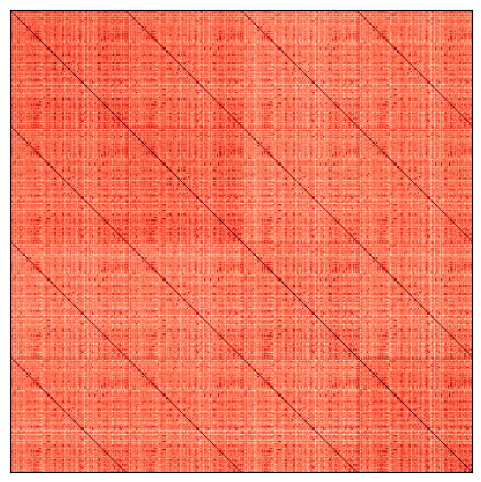

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(cs, cmap='Reds')
plt.xticks([])
plt.yticks([])
plt.show()

# fig, ax = plt.subplots(figsize=(6, 6))
# plt.imshow(dis, cmap='Reds')
# plt.xticks([])
# plt.yticks([])
# plt.show()

## t-sne

In [12]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (4, 3)

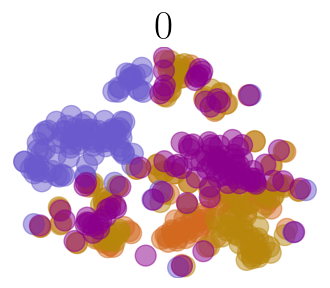

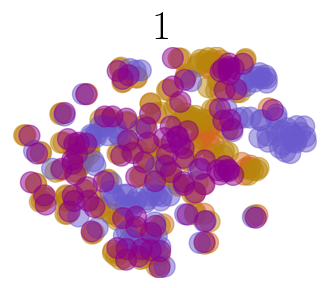

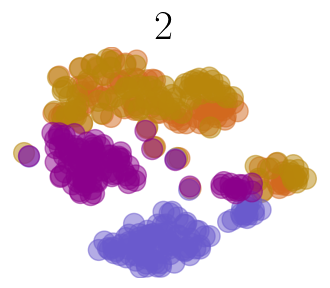

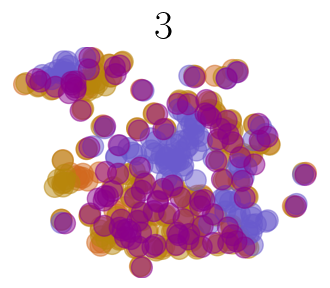

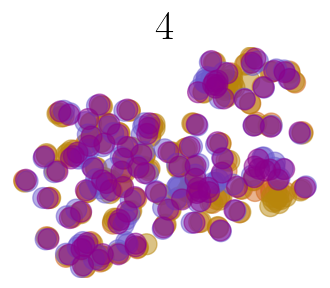

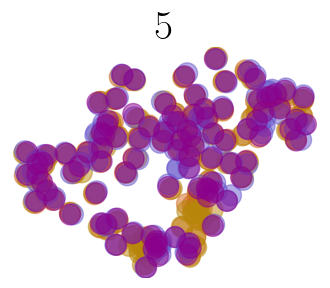

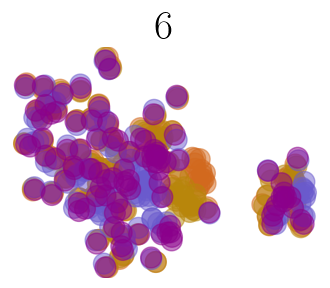

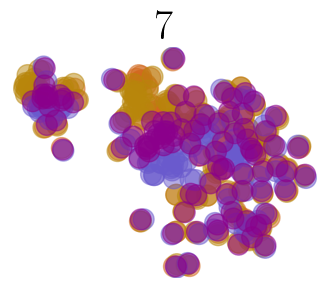

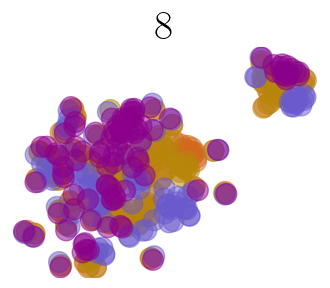

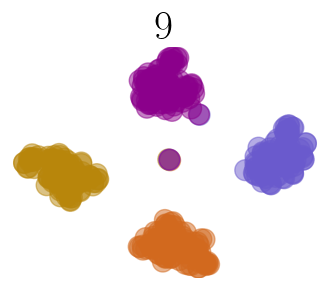

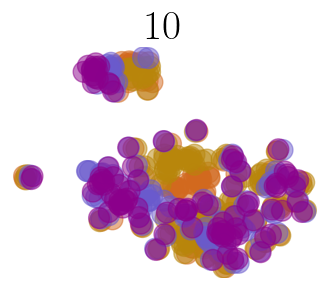

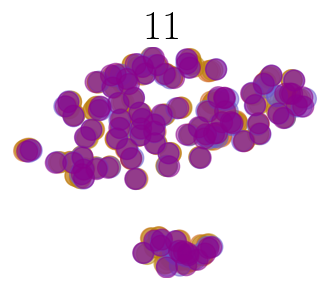

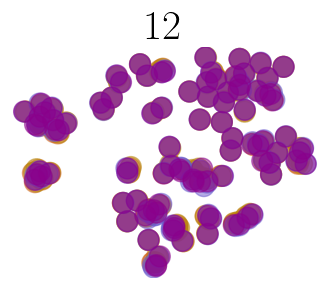

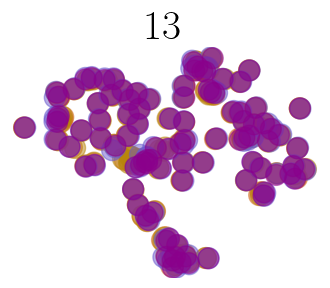

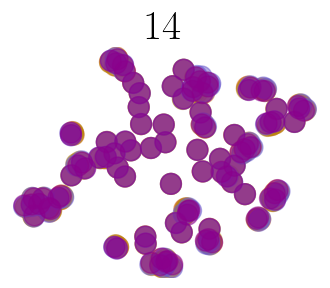

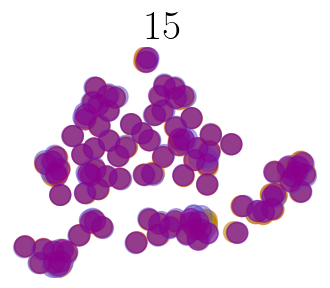

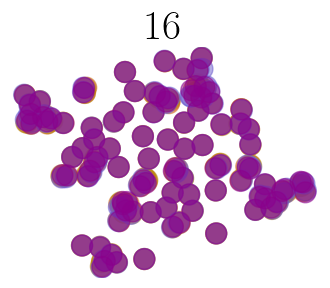

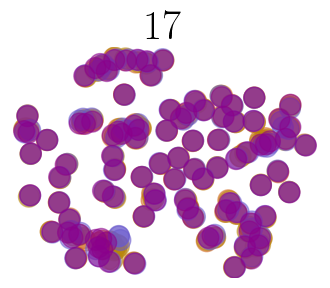

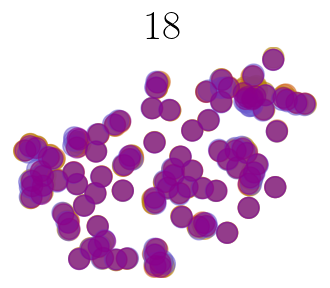

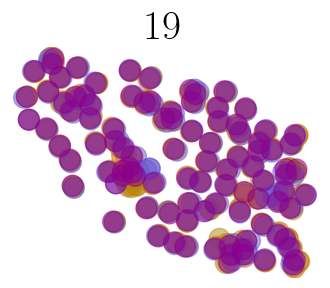

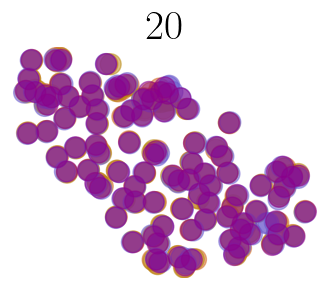

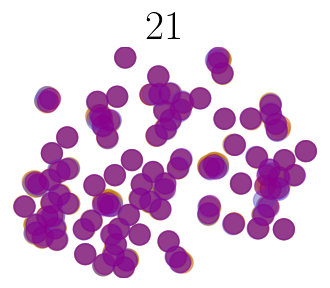

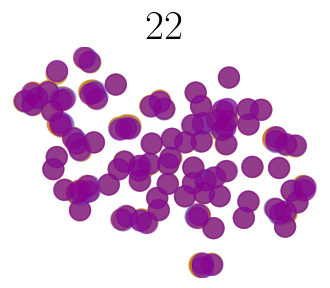

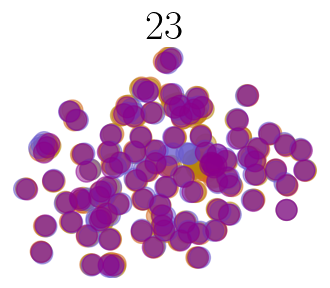

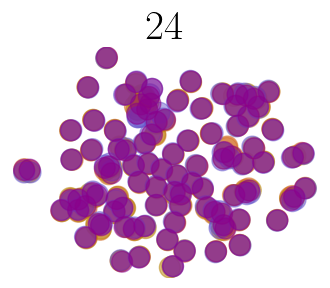

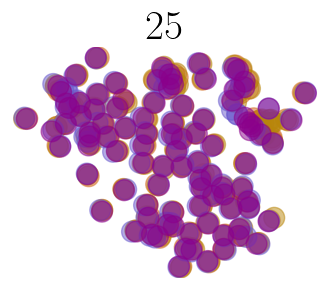

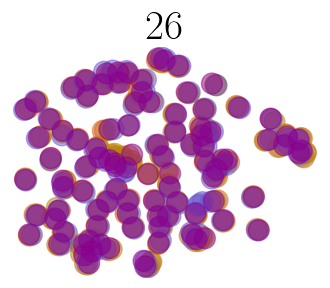

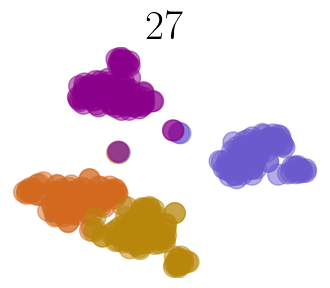

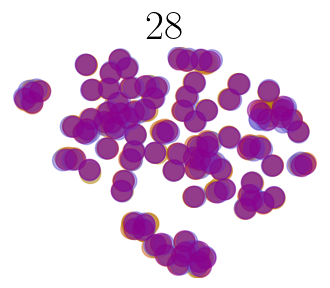

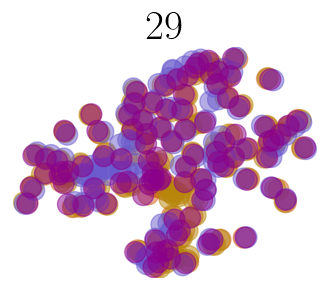

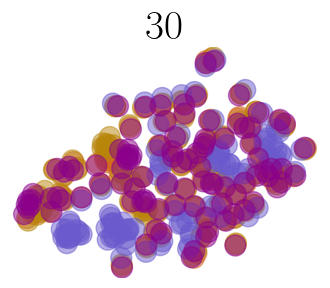

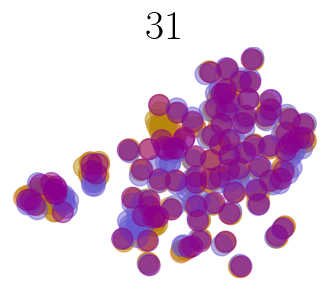

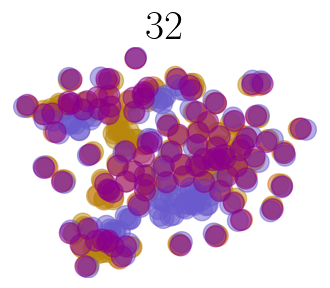

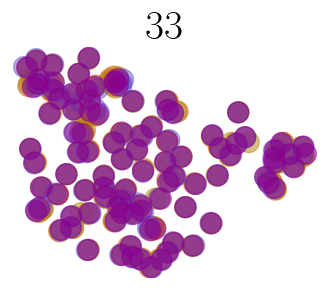

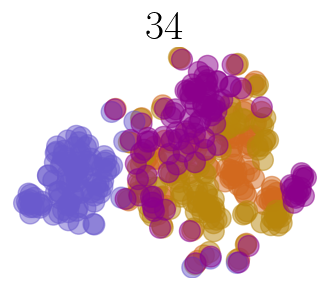

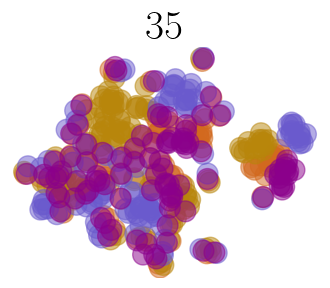

In [13]:
colors = []
for i in range(len(all_prompts_concepts)):
    if (language[i] == 'python'):
        colors.append('slateblue')
    if (language[i] == 'c++'):
        colors.append('darkgoldenrod')
    if (language[i] == 'java'):
        colors.append('chocolate')
    if (language[i] == 'javascript'):
        colors.append('darkmagenta')


for target_layer in target_layers:

    cur_concepts = []
    for i in range(len(prompts)):
        cur_concepts.append(all_prompts_concepts[i][target_layer])
    cur_concepts = torch.stack(cur_concepts, dim=0).squeeze()

    cur_concepts_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=20, random_state=0).fit_transform(cur_concepts.detach().cpu().float().numpy())

    plt.scatter(cur_concepts_emb[:, 0], cur_concepts_emb[:, 1], c=colors, alpha=0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(target_layer)
    plt.show()

In [17]:
target_layer = 24

In [18]:
cur_concepts = []
for i in range(len(prompts)):
    cur_concepts.append(all_prompts_concepts[i][target_layer])
cur_concepts = torch.stack(cur_concepts, dim=0).squeeze()

In [19]:
cur_concepts.shape

torch.Size([400, 4096])

In [20]:
cur_concepts_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=8, random_state=0).fit_transform(cur_concepts.detach().cpu().float().numpy())

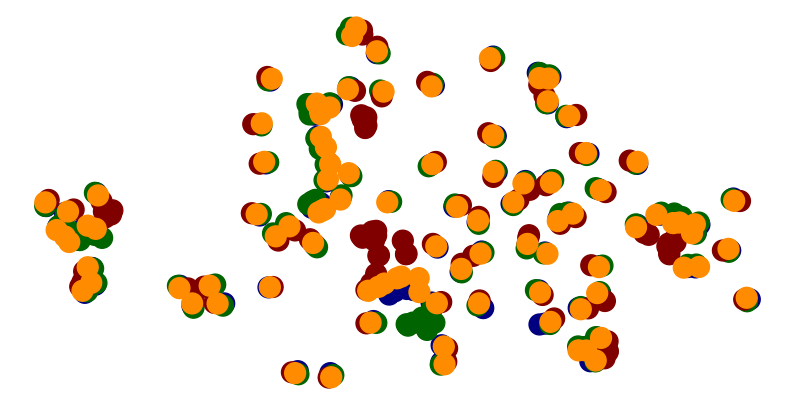

In [21]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (10, 5)

colors = []
for i in range(cur_concepts_emb.shape[0]):
    if (language[i] == 'python'):
        colors.append('maroon')
    if (language[i] == 'c++'):
        colors.append('darkgreen')
    if (language[i] == 'java'):
        colors.append('navy')
    if (language[i] == 'javascript'):
        colors.append('darkorange')

plt.scatter(cur_concepts_emb[:, 0], cur_concepts_emb[:, 1], c=colors)
plt.xticks([])
plt.yticks([])
plt.show()

# Transpiler

In [19]:
for hook in hooks:
    hook.remove()

## hook

In [20]:
hook.remove()
stop

NameError: name 'stop' is not defined

In [21]:
target_language = 'javascript'
strength = 1

if (model_name == 'llama'):
    target_layer = 19
elif (model_name == 'gemma'):
    target_layer = 32


def change_behavior(target_layer):
    def hook(model, input, output):
        output = (output[0] + strength*concepts[target_language][target_layer].to(device), *output[1:])
        # output = ((1-strength)*output[0] + strength*concepts[target_language][target_layer].to(device), *output[1:])
        return output
    return hook


hook = model.model.layers[target_layer].self_attn.register_forward_hook(change_behavior(target_layer))

In [96]:
def extract_program(prompt, target_language, source_language):



    if (target_language == 'c++'):
        target_language = 'cpp' 

    splits = re.split(r'\b' + target_language, prompt)[1:]

    for i in range(len(splits)):
        splits[i] = re.split(r'```', splits[i])[0].strip()
    
    for i in range(len(splits)):
        if (len(splits[i]) > 30):
            return splits[i]
        

    splits = re.split(r'\b' + '%s|%s' %(target_language, source_language), prompt)[1:]

    for i in range(len(splits)):
        splits[i] = re.split(r'```', splits[i])[0].strip()
    
    for i in range(len(splits)):
        if (len(splits[i]) > 30):
            return splits[i]

    return ''


## Exploration

In [124]:
python_task = ds[300]['python']
js_task = ds[300]['javascript']
cpp_task = ds[300]['c++']
java_task = ds[300]['java']

prompt = f"Re-state the following program. "
# prompt = f"Give a single, different re-writing of this program with the same function. "
# prompt += f"The output will be judged by an expert in all programming languages. "
# prompt += f"Do not include an explanation.\n\n```{python_task}```"
prompt += f"Do not include an explanation.\n\n```{python_task}```"

In [130]:
concepts['javascript'][32]

tensor([[-0.0090,  0.0087,  0.0079,  ...,  0.0408, -0.0074,  0.0024]])

In [146]:
target_language = 'javascript'

# print ('[white]%s[/white]' %(js_task))

for strength in [0]:

    with torch.inference_mode():
        with torch.no_grad():
            inputs = tokenizer(prompt, return_tensors="pt").input_ids
            outputs = model.generate(inputs.to(device), max_new_tokens=inputs.shape[1]*2, 
                                     do_sample=False, top_k=20, top_p=0.95, pad_token_id=tokenizer.eos_token_id, use_cache=False).detach().cpu()
            output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
    # output_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print ('-------------------------------------------------')
    print (strength)
    print (output_text)

    # print ('[white]%s[/white]' %(extract_program(output_text, target_language)))
        
    activations = {}

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:623: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
--- Logging error ---
Traceback (most recent call last):
  File "/home/takis/anaconda3/envs/unlearning/lib/python3.11/logging/__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/takis/anaconda3/envs/unlearning/lib/python3.11/logging/__init__.py", line 953, in format
    return fmt.format(record)
  

KeyboardInterrupt: 

## Validation dataset

In [101]:
val_size = 100

In [102]:
np.random.seed(0)
val_idxs = np.random.choice(list(range(keep, len(ds))), size=val_size, replace=False)


In [103]:
val_ds = Dataset.from_dict(ds[val_idxs])
val_ds

Dataset({
    features: ['id', 'slug', 'title', 'difficulty', 'content', 'java', 'c++', 'python', 'javascript'],
    num_rows: 100
})

### Translations

In [104]:
for source in ['java', 'c++', 'python', 'javascript']:
    for target in ['java', 'c++', 'python', 'javascript']:

        if (source == target):
            continue

        target_language = target
        



        strength = 6
        # if ('%s->%s' %(source, target) in ['c++->java', 'python->java', 'python->javascript', 'javascript->java', 'java->javascript', 'java->python']):
        #     preds = len(val_ds)*['']
        #     continue

        if (target != 'c++'):
            preds = len(val_ds)*['']
            continue
        
        preds = []

        for val_idx in tqdm(range(len(val_ds)), desc='%s->%s' %(source, target)):
        
            prompt = f"Re-state the following program. "
            prompt += f"Do not include an explanation.\n\n```{val_ds[val_idx][source]}```"

            with torch.inference_mode():
                with torch.no_grad():
                    inputs = tokenizer(prompt, return_tensors="pt").input_ids
                    outputs = model.generate(inputs.to(device), max_new_tokens=int(inputs.shape[1]*1.8), do_sample=False, top_k=20, top_p=0.95, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
                    output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
            
            # print ('[white]%s[/white]' %(output_text))

            preds.append(extract_program(output_text, target_language, source))

        val_ds = val_ds.add_column('%s->%s' %(source, target), preds)

javascript->c++: 100%|██████████| 100/100 [44:03<00:00, 26.44s/it]


In [105]:
val_ds.save_to_disk('programming_%s.hf' %(model_name))

Saving the dataset (1/1 shards): 100%|██████████| 100/100 [00:00<00:00, 24333.14 examples/s]


In [106]:
val_ds

Dataset({
    features: ['id', 'slug', 'title', 'difficulty', 'content', 'java', 'c++', 'python', 'javascript', 'java->c++', 'python->c++', 'javascript->c++'],
    num_rows: 100
})

In [59]:
val_ds = load_from_disk('programming_%s.hf' %(model_name))

In [60]:
val_ds

Dataset({
    features: ['id', 'slug', 'title', 'difficulty', 'content', 'java', 'c++', 'python', 'javascript', 'java->c++', 'c++->python', 'c++->javascript', 'python->c++', 'javascript->c++', 'javascript->python'],
    num_rows: 100
})

In [108]:
for source in ['java', 'c++', 'python', 'javascript']:
    for target in ['java', 'c++', 'python', 'javascript']:

        if (source == target):
            continue
            
        try:
            empty = np.sum([1 if len(val_ds[i]['%s->%s' %(source, target)]) < 10 else 0 for i in range(len(val_ds))])
            print ('%s->%s' %(source, target), empty)
        except:
            pass

java->c++ 41
python->c++ 1
javascript->c++ 8


In [ ]:
for source in ['java', 'c++', 'python', 'javascript']:
    for target in ['java', 'c++', 'python', 'javascript']:

        if (source == target):
            continue

        if (not (source == 'java' and target == 'c++')):
            continue

        target_language = target
        strength = 10
        preds = []

        for val_idx in tqdm(range(len(val_ds)), desc='%s->%s' %(source, target)):
        
            prompt = f"Re-state the following program. "
            prompt += f"Do not include an explanation.\n\n```{val_ds[val_idx][source]}```"

            with torch.inference_mode():
                with torch.no_grad():
                    inputs = tokenizer(prompt, return_tensors="pt").input_ids
                    outputs = model.generate(inputs.to(device), max_new_tokens=int(inputs.shape[1]*1.8), do_sample=False, top_k=20, top_p=0.95, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
                    output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
            
            print (output_text)
            print ('\n\n--------------------------------------------------\n\n')

            preds.append(extract_program(output_text, target_language, source))

        

java->c++:   1%|          | 1/100 [00:21<35:08, 21.30s/it]

 
    ```java
public int minRepeatsToSubstring(String a, String b) {
    int times = (b.length() + a.length() - 1) / a.length();

    for (int i = 0; i < 2; i++) {
        StringBuilder repeated_a = new StringBuilder();
        for (int j = 0; j < times + i; j++) {
            repeated_a.append(a);
        }

        if (repeated_a.toString().contains(b)) return times + i;
    }

    return -1;
}
```
    
    The algorithm calculates the minimum number of times string `a` must be repeated to have a length >= length of string `b`, which is done by `times = (b.length() + a.length() - 1) / a.length()`. Then, the algorithm checks if `b` is a substring of the concatenated string `a` after repeating it n number of times (n being `times` and `times+1`). If it finds `b` as a substring in any of the two cases, it returns the number of times `a` is repeated. If not found, it returns -1.
    ``` 
    ```java
public int minRepeatsToSubstring(String a, String b) {
    int times = (b.length() + a.le

java->c++:   2%|▏         | 2/100 [00:50<42:47, 26.20s/it]

`
    ```java
int minStepsToMakePalindrome(string s) {
    int n = s.size();
    vector<vector<int>> dp(n, vector<int>(n));
    for (int i = n - 2; i >= 0; i--) {
        for (int j = i + 1; j < n; j++) {
            if (s[i] == s[j]) {
                dp[i][j] = dp[i + 1][j - 1];
            } else {
                dp[i][j] = 1 + min(dp[i + 1][j], dp[i][j - 1]);
            }
        }
    }
    return dp[0][n - 1];
}
```
    
    We use dynamic programming to find the minimum number of steps required to make a string palindrome. The `dp[i][j]` element of the 2D `dp` array represents the minimum number of steps required to make a palindrome from substring `s[i..j]`. We iterate through the string in reverse order, and for each pair of characters, if the characters are equal, we update the `dp[i][j]` value using the `dp[i+1][j-1]`. If they are not equal, we update the `dp[i][j]` using the minimum value between `dp[i+1][j]` and `dp[i][j-1]`, adding 1 to it. In the end, we return the val

java->c++:   3%|▎         | 3/100 [01:16<41:38, 25.76s/it]

...

java->c++:  22%|██▏       | 22/100 [10:18<40:27, 31.12s/it]

java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java
    ```java

java->c++:  22%|██▏       | 22/100 [10:52<38:32, 29.65s/it]


KeyboardInterrupt: 

: 

In [98]:
empty = np.sum([1 if len(preds[i]) < 10 else 0 for i in range(len(preds))])
print (empty)

0


## Evaluation

https://github.com/dmbeaglehole/neural_controllers/blob/4b1ca371a2d7b6abc7ae648efe001f98352bbd0f/quantitative_comparisons/programming.py#L107

In [111]:
with open('../openai_token.txt', 'r') as f:
    openai_api_key = f.readline()

In [112]:
client = OpenAI(api_key=openai_api_key)

In [119]:
source = 'javascript'
target = 'c++'

scores = []

for i in tqdm(range(len(val_ds))):


    # prompt="Rate the translation of the original program to %s from 1 to 5. Do not reduce score for name changes." %(target)
    prompt="Rate the translation of the original program from 1 to 5. Do not reduce score for name changes." 
    prompt+="Give your response in the format '{score}/5. {Reason}'."
    prompt+="-"*60
    prompt+=f"\nORIGINAL: {val_ds[i][target]}\n"
    prompt+="-"*60
    prompt+=f"\nTRANSLATION: {val_ds[i]['%s->%s' %(source, target)]}"

    response = client.chat.completions.create(model="gpt-4.1-nano",
                                            messages=[{"role": "system", "content": "You are a helpful assistant."},
                                                    {"role": "user", "content": prompt}],
                                            max_tokens=20,
                                            temperature=0.0)

    overall_score = response.choices[0].message.content

    scores.append(overall_score)

100%|██████████| 100/100 [00:34<00:00,  2.87it/s]


In [120]:
for s in scores:
    print (s.split('.')[0])

4/5
4/5
4/5
2/5
4/5
4/5
4/5
4/5
4/5
2/5
4/5
3/5
4/5
4/5
4/5
4/5
4/5
4/5
4/5
4/5
2/5
4/5
4/5
4/5
4/5
3/5
4/5
4/5
3/5
Please provide the translated code so I can evaluate it
4/5
4/5
4/5
4/5
4/5
4/5
4/5
3/5
3/5
3/5
3/5
4/5
4/5
4/5
3/5
4/5
3/5
3/5
4/5
4/5
4/5
4/5
4/5
2/5
3/5
Please provide the translated code so I can evaluate it
2/5
4/5
4/5
4/5
4/5
2/5
2/5
4/5
4/5
4/5
3/5
4/5
4/5
4/5
4/5
3/5
2/5
4/5
4/5
4/5
2/5
4/5
4/5
4/5
3/5
4/5
4/5
4/5
4/5
4/5
4/5
4/5
4/5
2/5
4/5
4/5
4/5
4/5
4/5
4/5
4/5
3/5
4/5
4/5


In [121]:
number_scores = []

for s in scores:
    try:
        number_scores.append(int(s[0]))
    except:
        number_scores.append(1)

print (np.mean(number_scores), np.std(number_scores))

3.59 0.7495998932764065


In [ ]:
# prompt="Does the translation have the same functionality as the original program and will it compile and run?"
# prompt+=" Simply state yes or no."
# prompt+="-"*60
# prompt+=f"\nORIGINAL: {original}\n"
# prompt+="-"*60
# prompt+=f"\nTRANSLATION: {translation}"

# response = client.chat.completions.create(model="gpt-4o",
#                                           messages=[{"role": "system", "content": "You are a helpful assistant."},
#                                                     {"role": "user", "content": prompt}],
#                                           max_tokens=125,
#                                           temperature=0.0)

# functionality_score = response.choices[0].message.content